# Starting tests to model 2025wny

## Drive setup and imports

In [4]:
drive = False
NERSC = True

if drive:
    from google.colab import drive
    drive.mount('/content/drive')
    base_dir = '/content/drive/MyDrive/repos/GL-PS'
if NERSC:
    base_dir = '/global/u1/o/osoler/repos/GL-PS'

import os
import sys

os.chdir(base_dir)
%ls

modeling/  notebooks/  README.md  src/  test.txt


In [5]:
!nvidia-smi
# When running from google drive
if drive:
    !pip install corner
    !pip install lenstronomy==1.13.2
    !pip install gigalens --no-deps

# When running on NERSC
if NERSC:
    gigalens_base_dir = '/global/u1/o/osoler/gigalens/src'
    if gigalens_base_dir not in sys.path:
        sys.path.append(gigalens_base_dir)
        #print(sys.path)

Thu Feb  5 14:14:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:03:00.0 Off |                    0 |
| N/A   30C    P0             56W /  400W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [6]:
# import modeling functions
from importlib import reload
import src.flux_ratios_pipeline_funcs
reload(src.flux_ratios_pipeline_funcs)
from src.flux_ratios_pipeline_funcs import *

# import gigalens functions
from gigalens.tf.inference import ModellingSequence
from gigalens.tf.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.tf.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.tf.profiles.light import sersic
from gigalens.tf.profiles.mass import sis, shear, epl, sie
from tensorflow_probability import distributions as tfd, bijectors as tfb

2026-02-05 14:15:03.592529: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-05 14:15:03.592571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-05 14:15:03.700111: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-05 14:15:03.820093: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 14:15:08.280879: W tensorflow/compiler/tf2

flux_ratios_pipeline_funcs.py version: 0.2.4
flux_ratios_pipeline_funcs.py version: 0.2.4


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDirectionArrows
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.visualization.wcsaxes import add_scalebar
from astropy.stats import sigma_clipped_stats



## Observational data



In [8]:

data_dir = base_dir + '/modeling/2025wny/data/'
psfr_path = 'nirc2_psf_psfr_stacked.npy'
psf_path = 'nirc2_psf_stacked.npy'
image_fits = 'nirc2_wny_full.fits'
image_fits_clean = 'nirc2_wny_full_clean.fits'
psf_photutil_path = 'wny_photutil_psf_fit.csv'

with fits.open(data_dir + image_fits) as hdul:
  heads = hdul[0].header
  data = hdul[0].data
  hdul.close()

  heads_clean = hdul[0].header
  heads_list = ['CD1_1', 'CD1_2', 'CD2_1', 'CD2_2']
  for hl in heads_list:
    heads_clean[hl] = float(heads[hl])
  heads_clean['RADESYSa'] = heads['RADECSYS']
wcs = WCS(heads_clean)

psfr = np.load(data_dir + psfr_path)
psf = np.load(data_dir + psf_path)
psf_photutil = pd.read_csv(data_dir + psf_photutil_path)


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-BEG to 60990.630833 from DATE-BEG.
Set MJD-END to 60990.632953 from DATE-END'. [astropy.wcs.wcs]


In [9]:
psf_photutil

,Unnamed: 0,x_fit,y_fit,flux_fit,x_err,y_err,flux_err
0,0,491.346959,624.391736,60.829975,0.041131,0.045180,0.686246
1,1,433.149259,411.246418,17.631145,0.085960,0.094008,0.412534
2,2,634.350728,333.624255,14.024787,0.118965,0.131048,0.457709
3,3,884.289485,600.654906,8.869229,0.156156,0.172022,0.379112


SKy mean: -8.86e-02, sky median: -8.88e-02, sky std: 4.88e-02


Text(0.5, 1.0, 'psf')

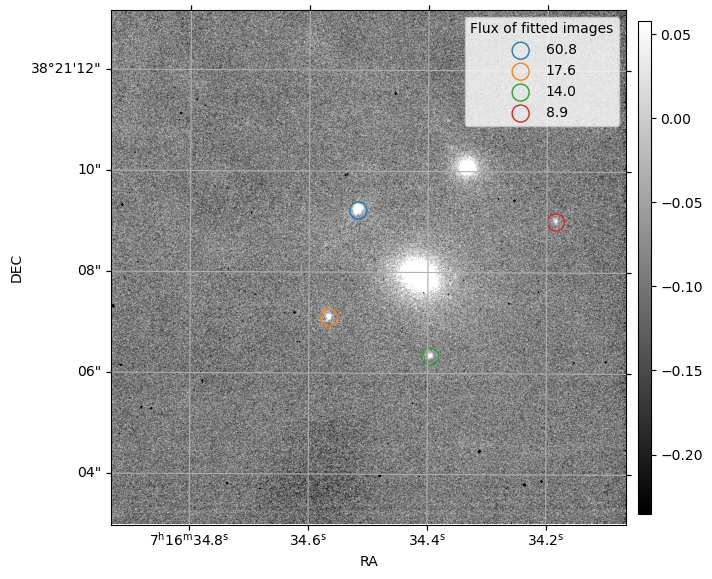

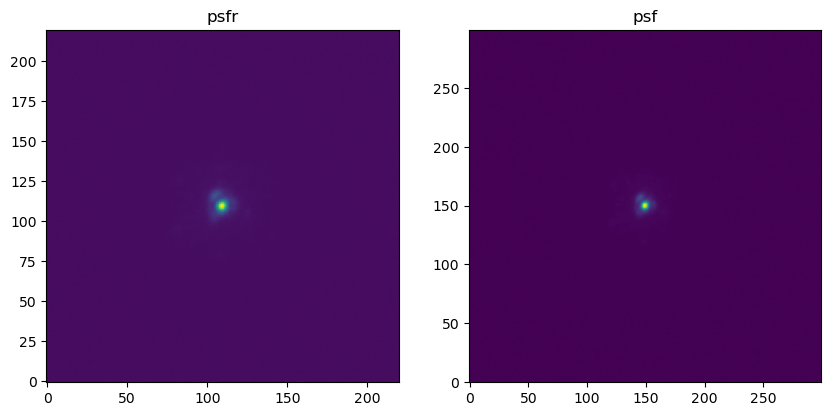

In [10]:
pixel_fit = np.array([psf_photutil['y_fit'].values, psf_photutil['x_fit'].values]).T
pixscale = 0.009952 # arcsec/px
exptime = 180

sky_mean, sky_median, sky_std = sigma_clipped_stats(data, sigma=3.0, maxiters=5)
print('SKy mean: %.2e, sky median: %.2e, sky std: %.2e'%(sky_mean, sky_median, sky_std))
bkg_rms = sky_std

stretch = 'linear'
percent = (5,99)
vminmax = (sky_mean - 3*sky_std,sky_mean + 3*sky_std)
# norm
norm = simple_norm(data, stretch,
                   #min_percent=percent[0], max_percent=percent[1],
                   #vmin = vminmax[0], vmax = vminmax[1])
                   min_cut = vminmax[0], max_cut = vminmax[1])
# figure
fig, ax = plt.subplots(1,1, figsize=(8,8))
fog, ax2 = plt.subplots(1,2, figsize=(10,5))
ax = [ax, ax2[0], ax2[1]]
ax[0].remove()
ax[0] = fig.add_subplot(1,1,1,projection=wcs)
im = ax[0].imshow(data, cmap='gray', origin = 'lower', norm = norm)
plt.colorbar(im, ax = ax[0],
             fraction = 0.15, aspect = 40, shrink = 0.8, pad = 0.02)
# images
for i in range(len(psf_photutil)):
  phot_row = psf_photutil.iloc[i]
  ax[0].scatter(phot_row['x_fit'], phot_row['y_fit'], label = '%.1f'%phot_row['flux_fit'],
             marker = 'o', s  = 150,
             facecolor = 'none', edgecolors=plt.get_cmap('tab10')(i), alpha = 1)
ax[0].legend(title = 'Flux of fitted images')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('DEC')
ax[0].grid()
# psfs
ax[1].imshow(psfr, origin = 'lower')
ax[1].set_title('psfr')

ax[2].imshow(psf, origin = 'lower')
ax[2].set_title('psf')

2026-02-05 14:17:18.898170: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
2026-02-05 14:17:18.901805: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38366 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
2026-02-05 14:17:18.905034: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38366 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
2026-02-05 14:17:18.907134: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38366 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bu

[[625 491]
 [495 611]
 [709 709]]


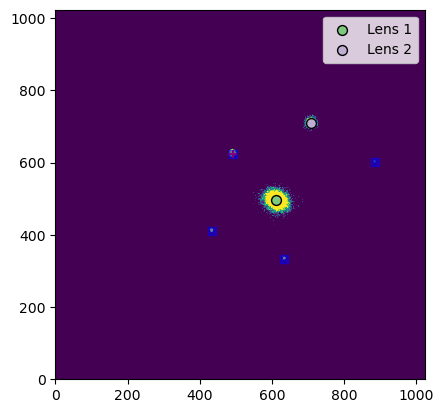

In [11]:
bp_converter = BrightestPoints(number_of_images = 3, num_pixels = data.shape[0],
                             grid_size = 50, delta_pix = pixscale,
                             supersample = 1)
bp_px = bp_converter.find_brightest_points(data)
print(bp_px.numpy())
plt.imshow(data, origin = 'lower', vmin=0, vmax = 0.1)
plt.scatter(bp_px[:,1], bp_px[:,0], c = 'r', marker='+')
plt.scatter(psf_photutil['x_fit'], psf_photutil['y_fit'], c = 'b', marker='s', alpha = 0.5)

lens1_px = bp_px[1]
lens2_px = bp_px[2]
pixel_lens = np.array([lens1_px, lens2_px])
for i, len_px in enumerate([lens1_px, lens2_px]):
  plt.scatter(len_px[1], len_px[0], marker='o', alpha = 1, s = 50, linewidths=1,
              edgecolors='black', facecolor = plt.get_cmap('Accent')(i), label = 'Lens %d'%(i+1))
plt.legend()

In [12]:

bp_converter = BrightestPoints(number_of_images = 4, num_pixels = data.shape[0],
                             grid_size = 20, delta_pix = pixscale,
                             supersample = 1)
x_arcsec, y_arcsec = bp_converter.pix_to_arcsec(pixel_fit)
x_arcsec_lens, y_arcsec_lens = bp_converter.pix_to_arcsec(pixel_lens)
print(x_arcsec, y_arcsec)

print(x_arcsec_lens, y_arcsec_lens)

flux_truth_test = tf.constant(psf_photutil['flux_fit'], dtype=tf.float32)
print(flux_truth_test)

tf.Tensor([-0.20401621 -0.78123224  1.2191198   3.70712   ], shape=(4,), dtype=float32) tf.Tensor([ 1.1195998  -1.0001762  -1.7764323   0.88075185], shape=(4,), dtype=float32)
tf.Tensor([0.9902238 1.9655199], shape=(2,), dtype=float32) tf.Tensor([-0.1642082  1.9655199], shape=(2,), dtype=float32)
tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)


# Model



In [14]:
xy_lens_1 = tf.constant([x_arcsec_lens[0].numpy(), y_arcsec_lens[0].numpy()], dtype=tf.float32)
xy_lens_2 = (x_arcsec_lens[1].numpy(), y_arcsec_lens[1].numpy())

# Uniform prior
lens_prior_uniform = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.Uniform(1.5, 3,),
          e1=tfd.Uniform(-0.1, 0.1),
          e2=tfd.Uniform(-0.1, 0.1),
          center_x=tfd.Uniform(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Uniform(xy_lens_1[1]-0.2, xy_lens_1[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Uniform(-0.1, 0.3),
           gamma2=tfd.Uniform(-0.1, 0.3),
          ),),])

# Normal distribution prior
lens_prior_norm = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.TruncatedNormal(2.25, 0.5, 1.2, 3), # changed lower bound
          e1=tfd.Normal(0, 0.1),
          e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Normal(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Normal(0.1, 0.2),
           gamma2=tfd.Normal(0.1, 0.2),
          ),),])

# physical model
phys_model = PhysicalModel(
    [ # mass profile
        epl.EPL(50), # 50 is the maximum number of iterations for calculating the deflection
        shear.Shear() # External shear model, parameterized by shear components ``gamma1`` and ``gamma2``
    ],
    [ # lens light
        sersic.SersicEllipse(), # defined by e1, e2 and center_x, center_y
    ],
    [ # source light (Point() defined in functions)
        Point()
    ]
)

# truth configuration list
truth_test = [
    [ # mass distribution
        {'theta_E': 0.167, 'gamma': 2.013, 'e1': 0.049, 'e2': 0.083, 'center_x': 0.05, 'center_y': 0.011},
        {'gamma1': 0.078, 'gamma2': 0.015}  # external shear
    ],
    [ # lensing galaxy light
        {'R_sersic': 0.350, 'n_sersic': 2.586, 'e1': -0.262, 'e2': 0.239, 'center_x': 0.011, 'center_y': -0.05, 'Ie': 250.055}
    ],
    [ # source light
        {'center_x': -0.04, 'center_y': 0.09, 'Ie': 2815.973}
    ]
]

Choosing a prior, creating the probabilistic model

In [15]:
lens_prior_chosen = lens_prior_uniform
prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# resolution
supersample = 1
num_pix = data.shape[0]
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)
# example of sampling from the prob model
example1 = lens_prior_chosen.sample(seed = 1)
example2 = lens_prior_chosen.sample(seed = 2)
example3 = lens_prior_chosen.sample(seed = 3)
print('Sample parameters')
for ex in [example1, example2, example3]:
    print('-----------------')
    print_formatted_dict(ex)

# size = int(tf.size(tf.nest.flatten(example)))
# kernel = np.load('/content/drive/MyDrive/point-source-updates/F475W-epsf.npy').astype(np.float32)
sim_config = SimulatorConfig(delta_pix=pixscale, num_pix=num_pix, supersample=supersample)

lens_sim = LensSimulator(phys_model, sim_config, bs=1)


Sample parameters
-----------------
 - theta_E   :    2.159240
   gamma     :    1.738230
   e2        :    0.044558
   e1        :    0.036768
   center_y  :   -0.287475
   center_x  :    0.862560
 - gamma2    :   -0.070352
   gamma1    :   -0.082135
-----------------
 - theta_E   :    2.935602
   gamma     :    1.731808
   e2        :    0.078100
   e1        :    0.014694
   center_y  :   -0.114032
   center_x  :    1.057679
 - gamma2    :    0.150283
   gamma1    :    0.127424
-----------------
 - theta_E   :    1.771553
   gamma     :    2.263635
   e2        :   -0.068169
   e1        :   -0.050824
   center_y  :   -0.342870
   center_x  :    0.861316
 - gamma2    :    0.288826
   gamma1    :    0.103792


2026-02-05 14:18:19.110625: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x563dfa9d84a0


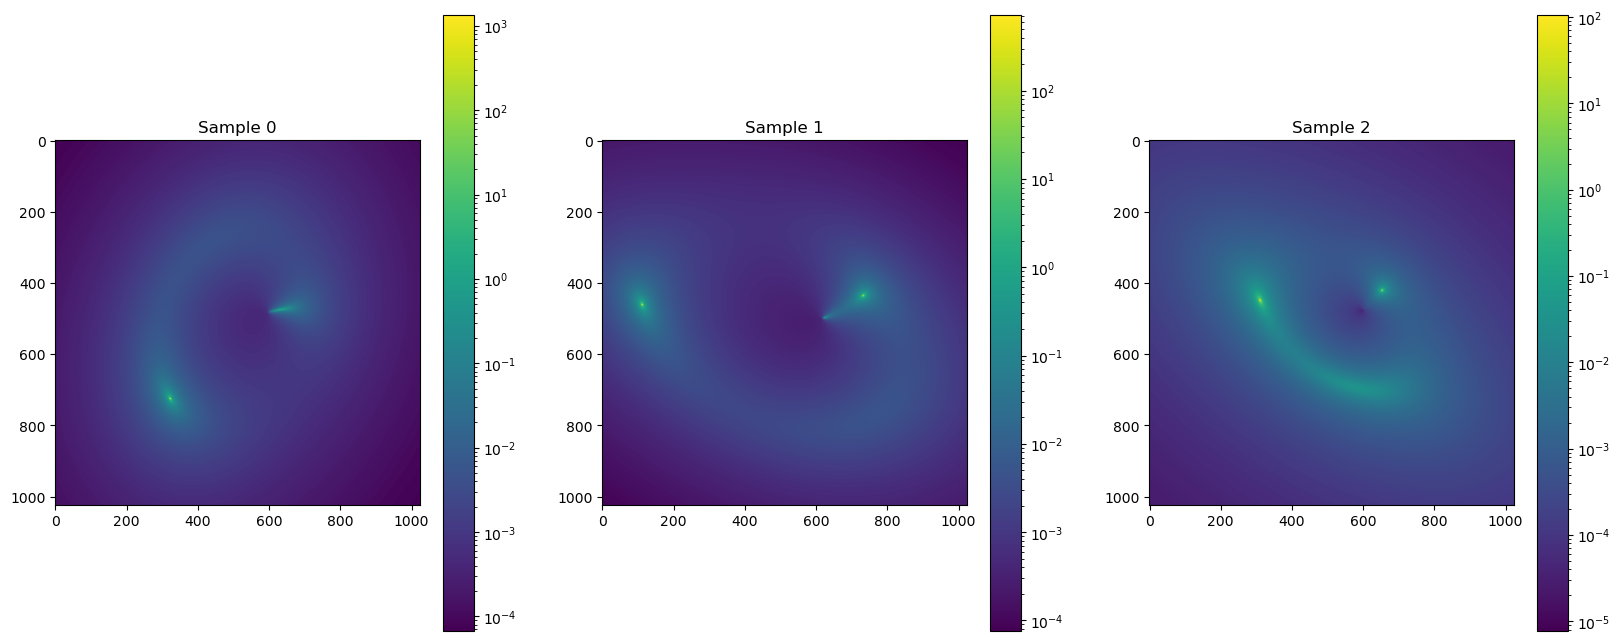

In [12]:
# simulated image with example of sampled mass distribution and truth source light
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
for i, ex in enumerate([example1, example2, example3]):
  sim_image = lens_sim.simulate([ex, [], truth_test[2]])
  im = ax[i].imshow(sim_image, norm = 'log')#, vmin=0, vmax=10)
  plt.colorbar(im, ax = ax[i])
  ax[i].set_title('Sample %i'%i)



    ============== weight_dist = 1.00e+02 | weight_flux = 1.00e+02 ==============


--- Modeling a real system ----


  0%|          | 0/1000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----

Best parameters:
 - theta_E   :    2.074638
   gamma     :    2.261149
   e2        :    0.116118
   e1        :    0.111271
   center_y  :    0.083353
   center_x  :    1.401818
 - gamma2    :    0.116977
   gamma1    :    0.112110


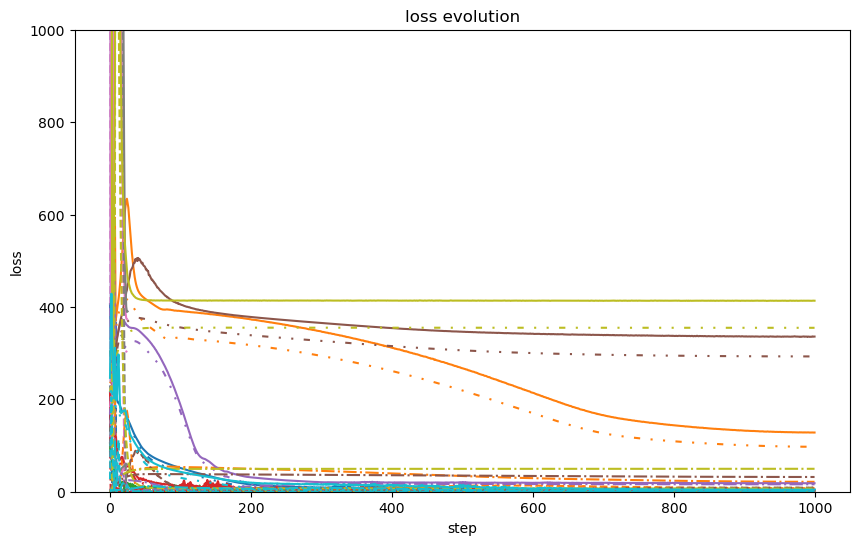


----- real system. comparing flux ratio difference ----


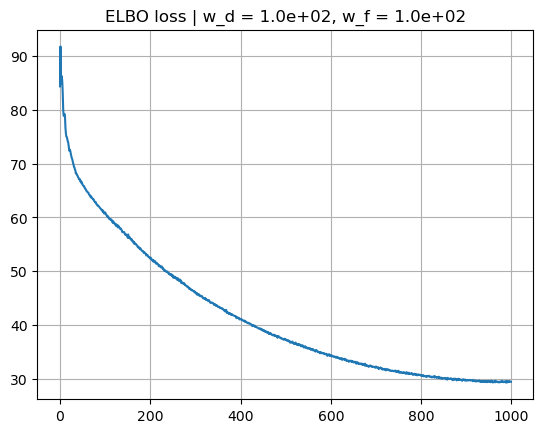


----- real system. comparing flux ratio difference ----


2026-02-05 14:45:57.965677: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'fusion_301', 16 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_808', 4 bytes spill stores, 4 bytes spill loads




----------------method: adaptative------------------



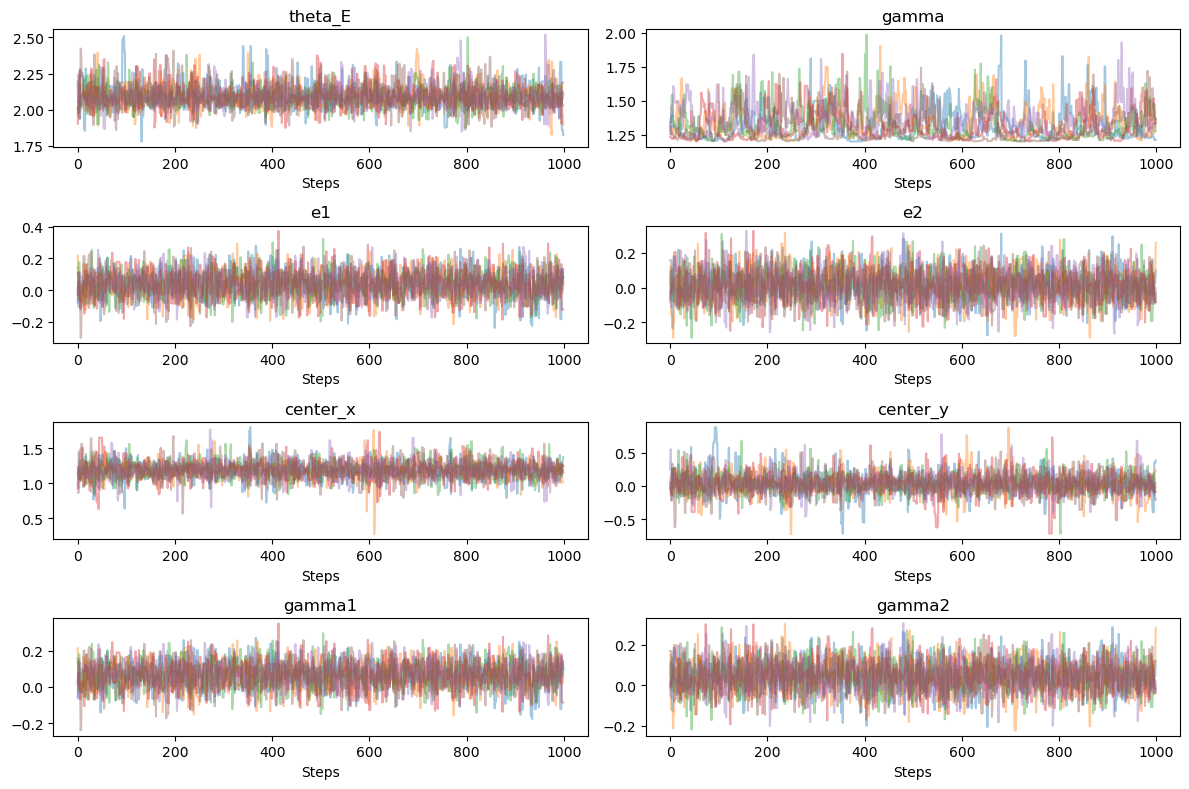


Rhat:
theta_E   :   1.002295
gamma     :   1.073767
e2        :   1.001851
e1        :   1.001481
center_y  :   1.001684
center_x  :   1.001643
gamma2    :   1.001316
gamma1    :   1.002272

ESS:
theta_E   :   162820.9
gamma     :     7628.1
e2        :   202537.6
e1        :   221535.4
center_y  :   183898.9
center_x  :   196537.4
gamma2    :   217020.0
gamma1    :   169540.6


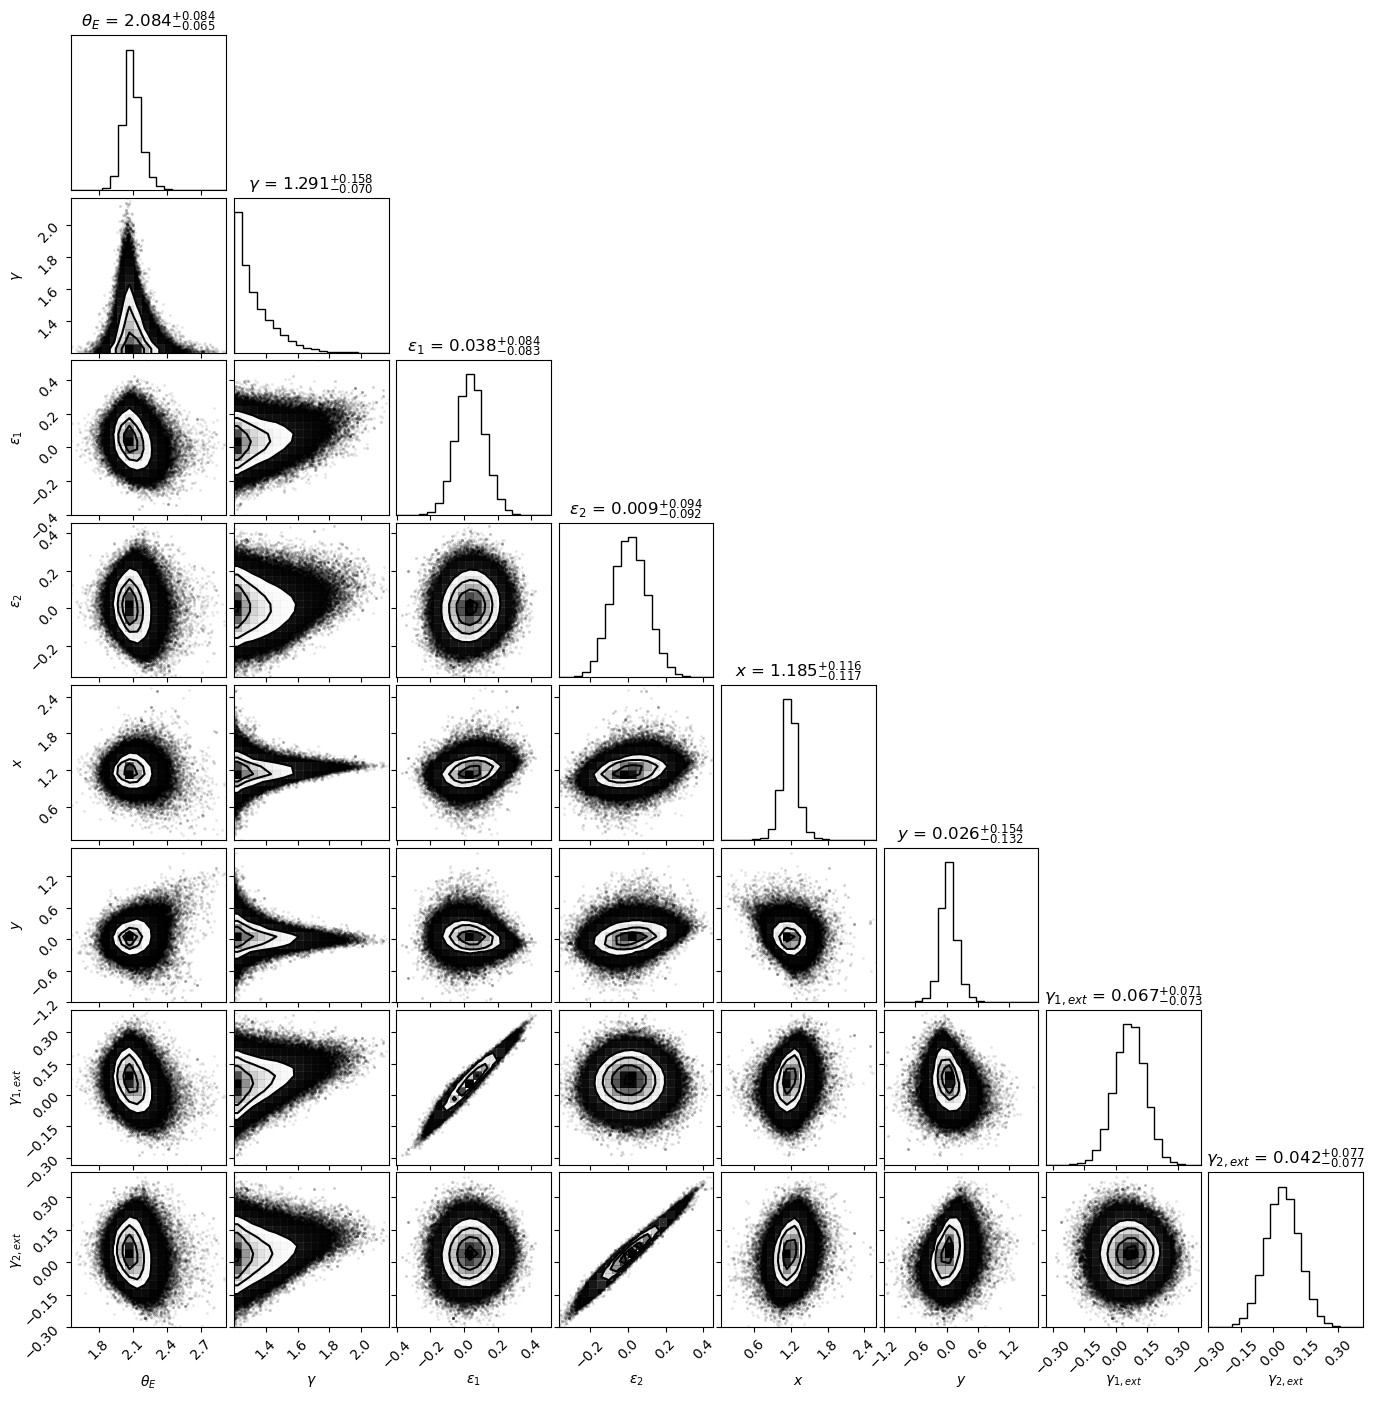

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.0930 |   2.0842
gamma      |   1.3299 |   1.2911
e1         |   0.0386 |   0.0381
e2         |   0.0103 |   0.0091
center_x   |   1.1850 |   1.1846
center_y   |   0.0354 |   0.0259
gamma1     |   0.0663 |   0.0674
gamma2     |   0.0425 |   0.0423


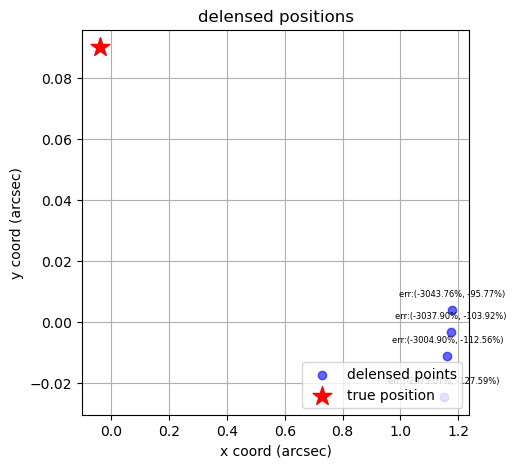

self.prob_model_output
 - theta_E   :    2.084241
   gamma     :    1.291142
   e2        :    0.009086
   e1        :    0.038147
   center_y  :    0.025890
   center_x  :    1.184645
 - gamma2    :    0.042284
   gamma1    :    0.067364


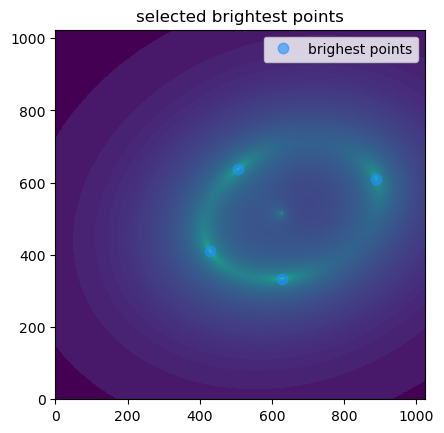

Brighest points reshaped into x, y:

x: [[ 1.1594079 ]
 [-0.8210402 ]
 [ 3.746928  ]
 [-0.04478421]]

y: [[-1.7764323]
 [-1.0200802]
 [ 0.9802718]
 [ 1.2489759]]
Kwargs lens
 - theta_E   :    2.084241
   gamma     :    1.291142
   e1        :    0.038147
   e2        :    0.009086
   center_x  :    1.184645
   center_y  :    0.025890
 - gamma1    :    0.067364
   gamma2    :    0.042284


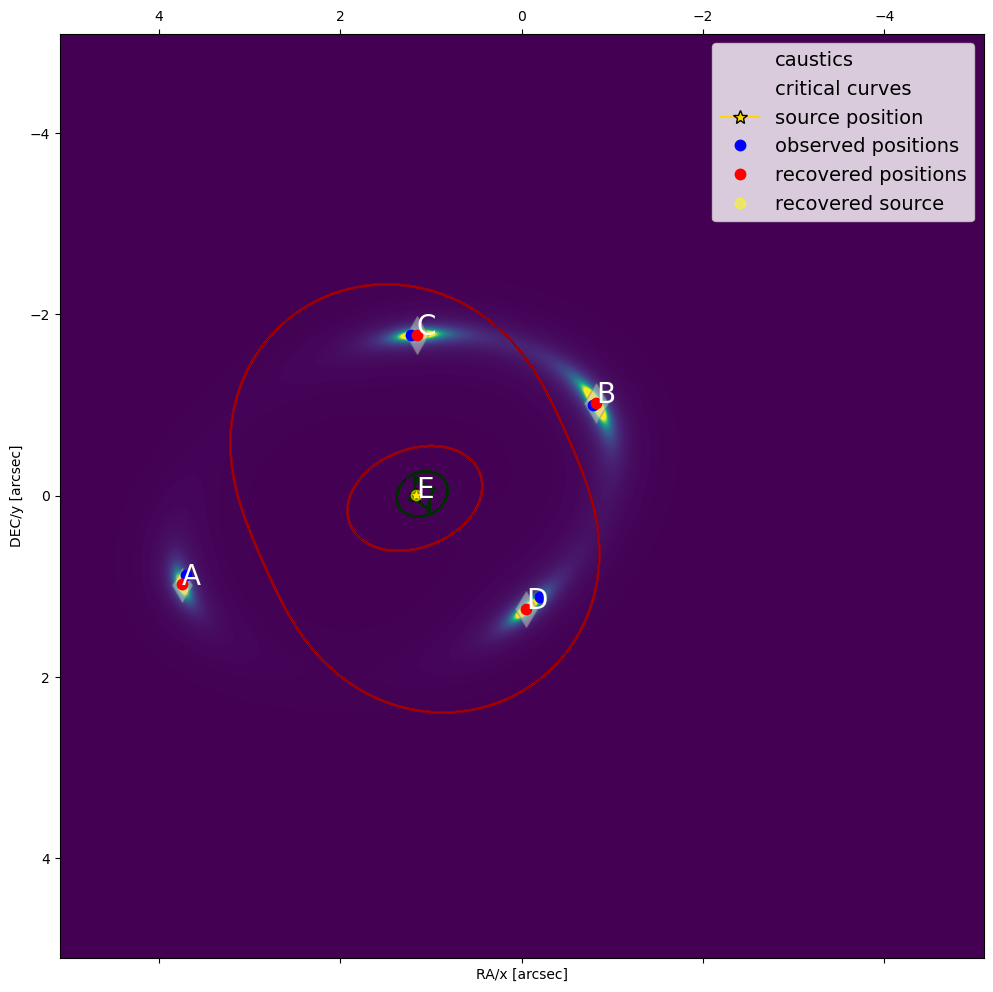


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[0.00152189]
 [0.0017103 ]
 [0.0025121 ]
 [0.00020293]
 [0.00051327]
 [0.00019237]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[0.4691923]
 [0.9873265]
 [1.9380506]
 [2.104311 ]
 [4.1306105]
 [1.9629277]]

relative errors (in observed positions):
flux1/flux2: 86.40%
flux1/flux3: 77.24%
flux1/flux4: 71.74%
flux2/flux3: 67.39%
flux2/flux4: 107.79%
flux3/flux4: 24.13%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854167], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[-45.56186 ]
 [ 60.22033 ]
 [ 29.757149]
 [-37.32624 ]]

Predicted magnifications (in observed positions):
 [[-44.257362]
 [ 64.75936 ]
 [-44.540504]
 

  0%|          | 0/1000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----

Best parameters:
 - theta_E   :    2.057791
   gamma     :    1.785493
   e2        :    0.026229
   e1        :    0.131764
   center_y  :   -0.053248
   center_x  :    1.338917
 - gamma2    :    0.058942
   gamma1    :    0.159899


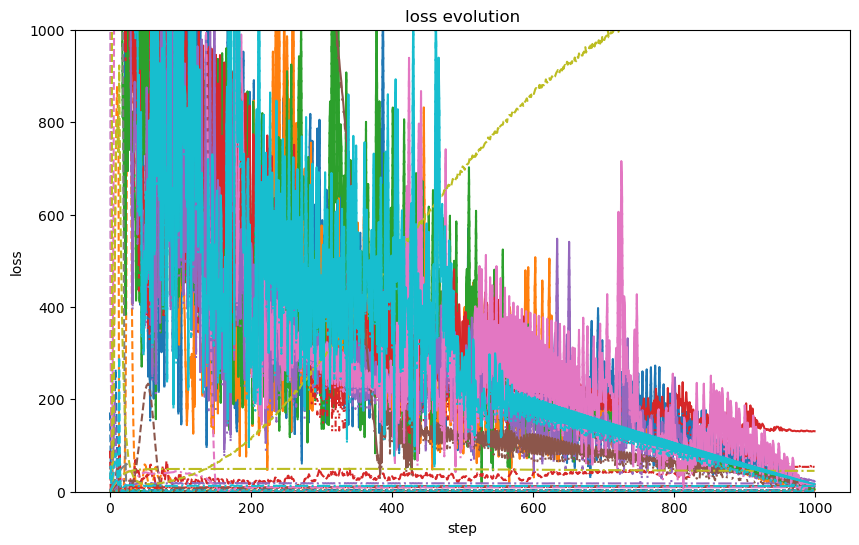


----- real system. comparing flux ratio difference ----


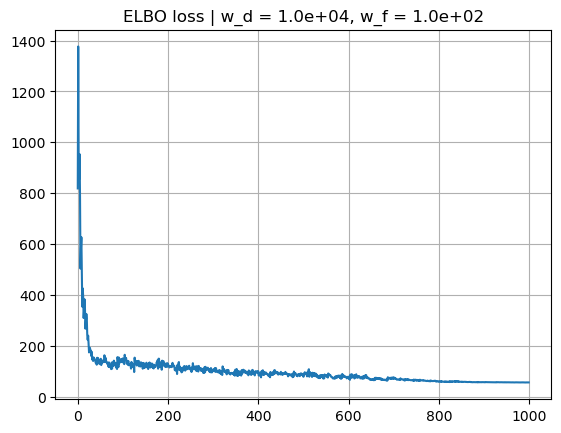


----- real system. comparing flux ratio difference ----


2026-02-05 14:52:55.847283: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'fusion_301', 16 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_808', 4 bytes spill stores, 4 bytes spill loads




----------------method: adaptative------------------



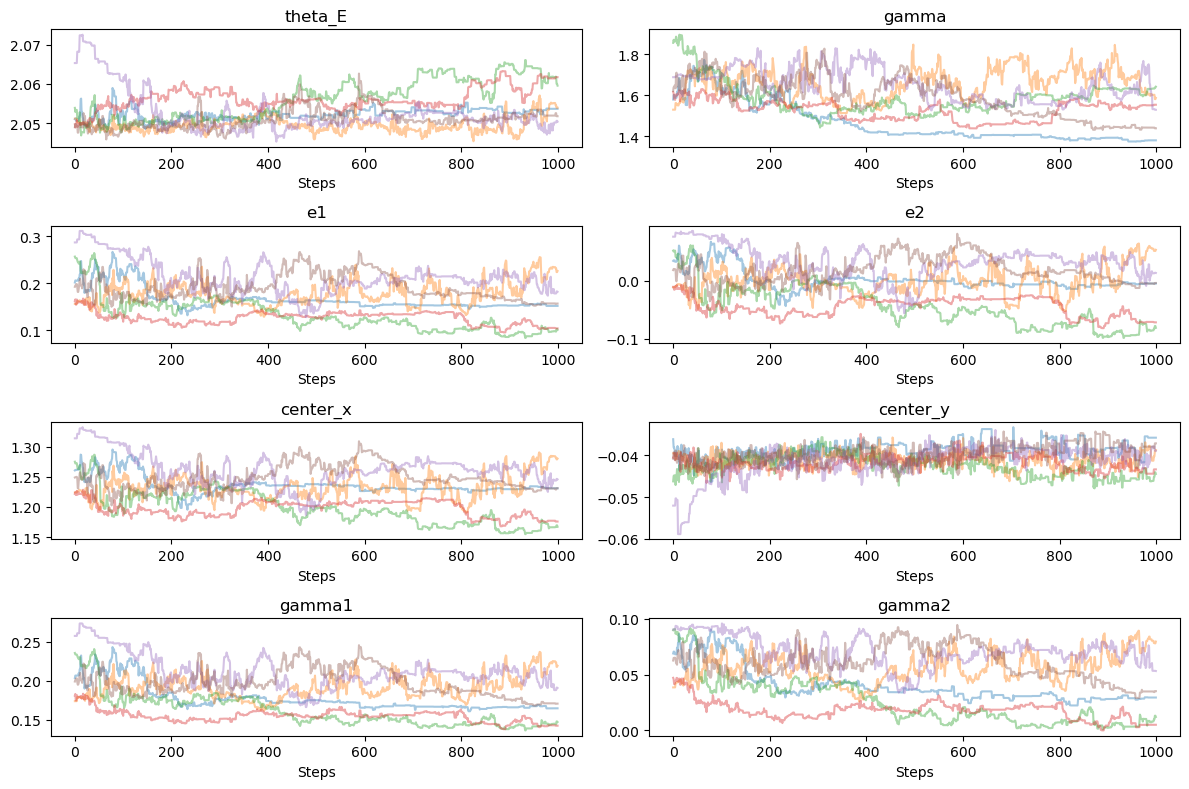


Rhat:
theta_E   :   1.696942
gamma     :   1.816864
e2        :   2.047738
e1        :   2.015249
center_y  :   1.558199
center_x  :   2.037845
gamma2    :   2.194613
gamma1    :   2.101802

ESS:
theta_E   :     1217.1
gamma     :     1112.0
e2        :      977.2
e1        :      992.5
center_y  :     1395.0
center_x  :      981.8
gamma2    :      918.6
gamma1    :      953.8


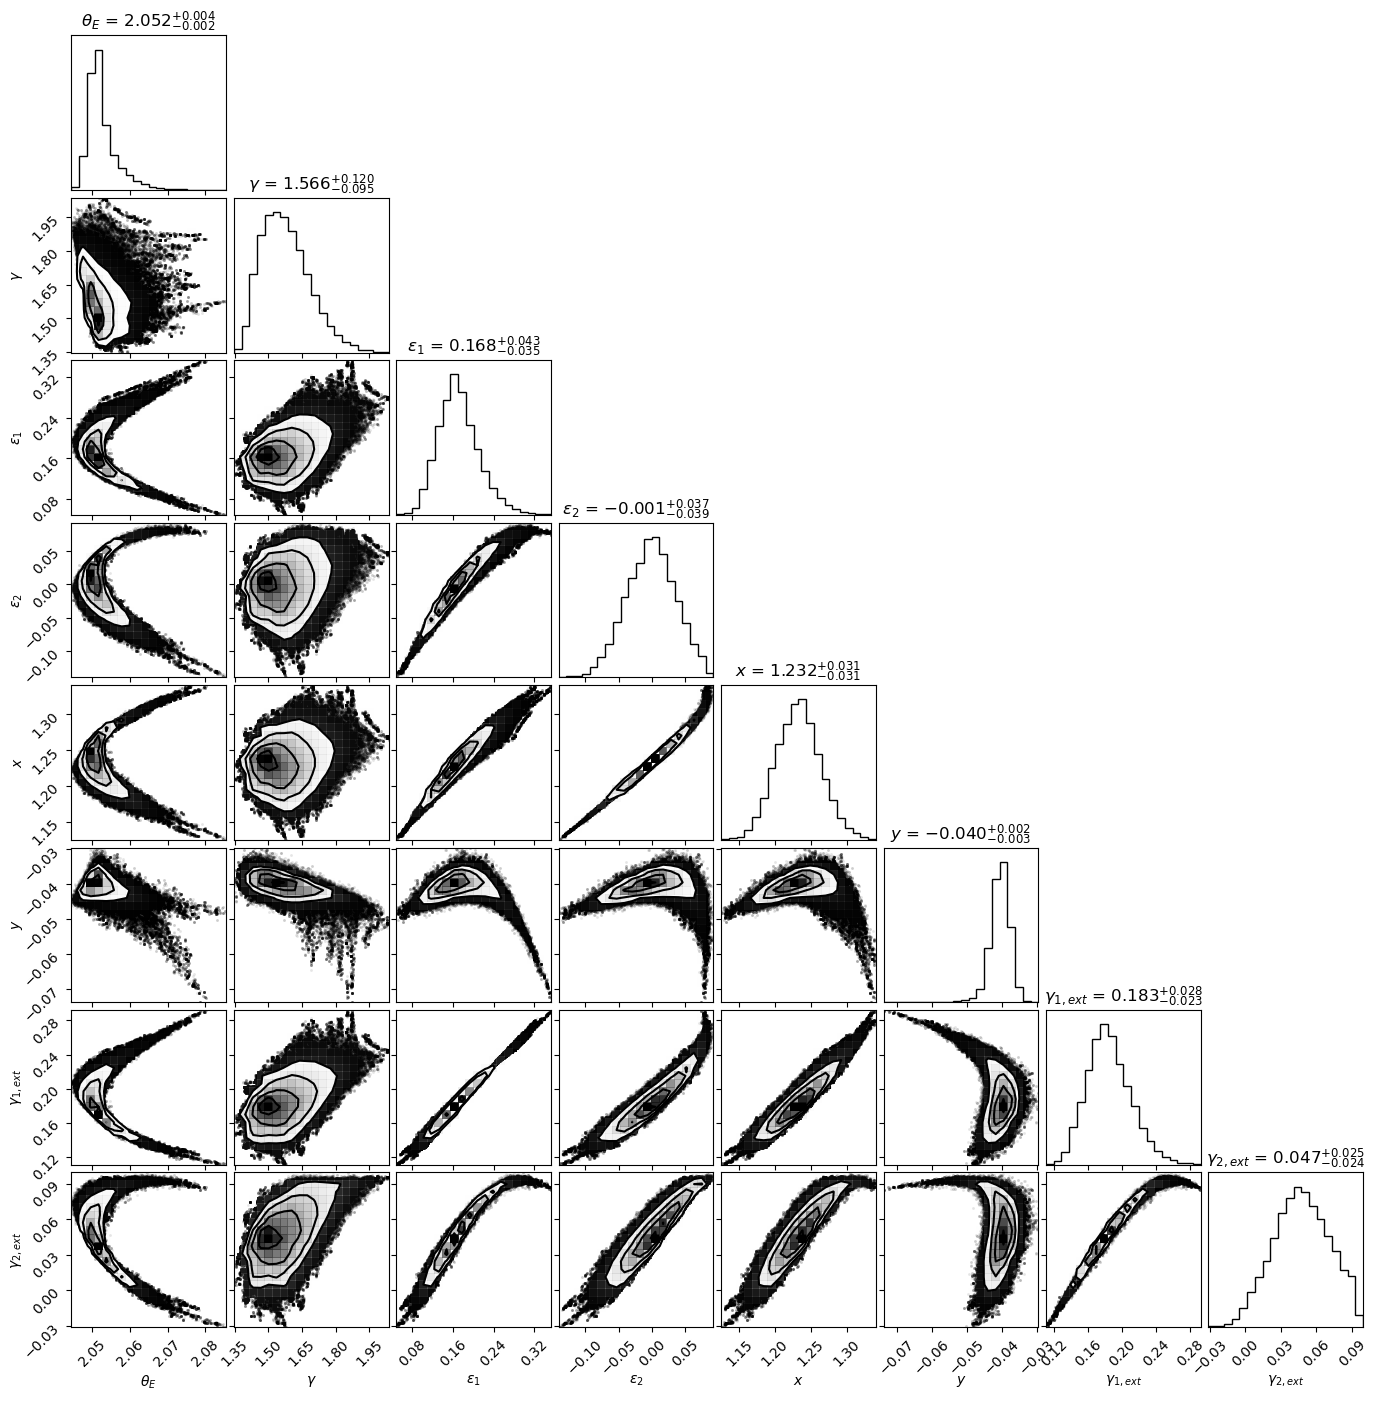

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.0527 |   2.0516
gamma      |   1.5791 |   1.5662
e1         |   0.1716 |   0.1678
e2         |  -0.0018 |  -0.0009
center_x   |   1.2325 |   1.2323
center_y   |  -0.0407 |  -0.0404
gamma1     |   0.1849 |   0.1827
gamma2     |   0.0473 |   0.0472


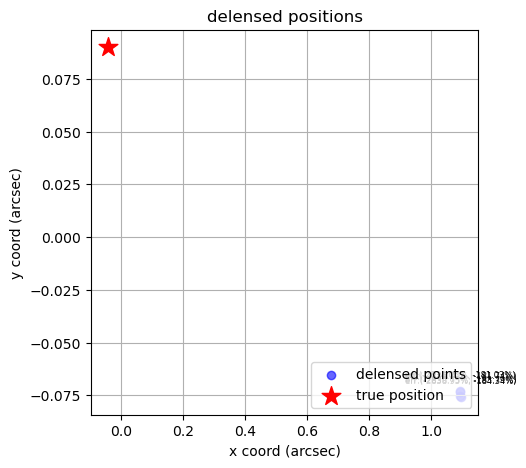

self.prob_model_output
 - theta_E   :    2.051556
   gamma     :    1.566195
   e2        :   -0.000939
   e1        :    0.167822
   center_y  :   -0.040415
   center_x  :    1.232275
 - gamma2    :    0.047181
   gamma1    :    0.182679


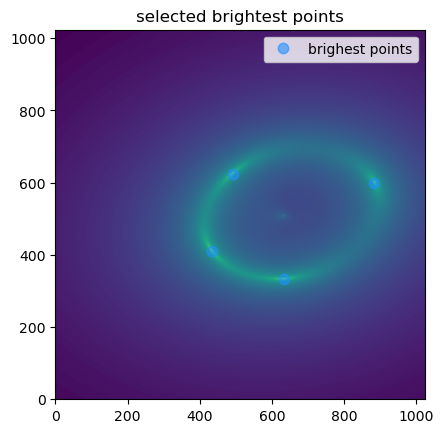

Brighest points reshaped into x, y:

x: [[ 3.70712   ]
 [-0.78123224]
 [-0.20401621]
 [ 1.2191198 ]]

y: [[ 0.88075185]
 [-1.0001762 ]
 [ 1.1195998 ]
 [-1.7764323 ]]
Kwargs lens
 - theta_E   :    2.051556
   gamma     :    1.566195
   e1        :    0.167822
   e2        :   -0.000939
   center_x  :    1.232275
   center_y  :   -0.040415
 - gamma1    :    0.182679
   gamma2    :    0.047181


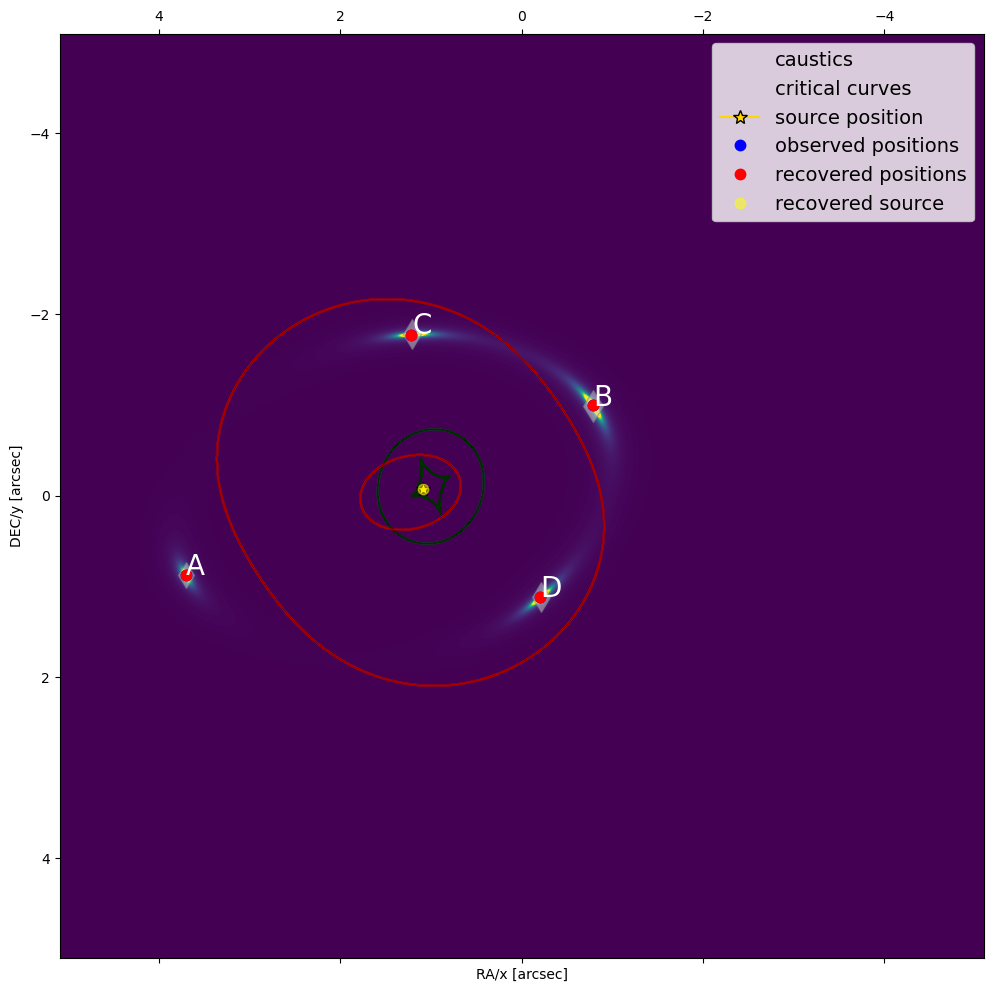


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[0.01268096]
 [0.01432127]
 [0.02092836]
 [0.0016205 ]
 [0.00428014]
 [0.00171767]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[0.4415381]
 [0.939545 ]
 [1.8932126]
 [2.127891 ]
 [4.2877674]
 [2.0150313]]

relative errors (in observed positions):
flux1/flux2: 87.20%
flux1/flux3: 78.34%
flux1/flux4: 72.40%
flux2/flux3: 69.26%
flux2/flux4: 115.69%
flux3/flux4: 27.43%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854167], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[ 11.21326 ]
 [ 23.18048 ]
 [-15.403042]
 [-15.877584]]

Predicted magnifications (in observed positions):
 [[-15.403042]
 [ 23.18048 ]
 [-15.877584]
 

In [17]:
# resolution
supersample = 1
num_pix = data.shape[0]
delta_pix = pixscale

# Modeling
observed_data = [[x_arcsec, y_arcsec], flux_truth_test]

lens_prior_chosen = lens_prior_norm
prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)

# Uniform prior
prior_uniform = tfd.JointDistributionSequential([lens_prior_uniform,])
prob_model_uniform = ForwardProbModel(prior_uniform, 0, background_rms=bkg_rms, exp_time=exptime)
losses_list = []
for wd in [1e2, 1e4]:#[1, 1e2, 1e4]: #, 1e1, 1e2]: #, 5e2, 1e3, 5e3]:
  for wf in [1e2]:#[1, 1e2, 1e4]: #, 5e2, 1e3, 5e3]:
    print('\n    ============== weight_dist = %.2e | weight_flux = %.2e ==============\n'%(wd,wf))
    analysis = LensModelAnalysis(delta_pix=pixscale, num_pix=num_pix, weight_dist=wd, weight_flux=wf, truth_test=truth_test,
                                prob_model=prob_model,
                                prior=prior,
                                #lens_prior = lens_prior,
                                phys_model = phys_model,
                                prob_model_uniform=prob_model_uniform,
                                observed_data = observed_data, simulation = False, flux_ratios = True)
    losses = analysis.run_map(n_map = 500, n_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 1e-4, 'power': 1.0},
                    uniform_comparison = False,
                    track_loss_all = True,
                    test_results_dict = {'relative_errors': False, 
                                         'plot_loss': True, 
                                         'flux_ratio_error': False, 
                                         'delensed_positions': False,},
                    return_loss = True)
    losses_list.append(losses)
    analysis.run_vi(n_vi = 500, num_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-2,
                                            'end_learning_rate': 1e-4,
                                            'power': 1.0})
    samples_phys = analysis.run_hmc(n_hmc=500, num_burnin_steps=200, num_results=1000, method = "adaptative",
                                     init_eps = 0.5, init_l = 3, max_leapfrog_steps = 100)
      

In [61]:
from matplotlib._pylab_helpers import Gcf

open_figs = [manager.canvas.figure for manager in Gcf.get_all_fig_managers()]
print(open_figs)

[]


- keep playing with different weights, learning rates and so to test results of ELBO loss,
- then run HMC too and compare results

- learning rate has to be fixed to avoid sudden crash at the end

- remove extra map with uniform prior

ELBO loss smooth plot with
```
n_map = 500, n_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 5e-3, 'power': 1.0}
```
```
n_vi = 500, num_steps = 1000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-5,
                                            'end_learning_rate': 4e-2,
                                            'power': 1.0}
```
- $w_d = $ 1, 10, 100 & $w_f=0$. Goes down from $\sim 70$ to $\sim 20$.
- $w_f>0$ $(w_f=0.1,\, 1, \, 10)$ more noisy but does not break down with SVI, **breaks down with HMC**

In [37]:
reload(src.flux_ratios_pipeline_funcs)
from src.flux_ratios_pipeline_funcs import *

flux_ratios_pipeline_funcs.py version: 0.2.4
